# Medical Imaging ML Project — Skin Lesion Classification

## Task 0: Project Scope

- **Body part / anatomical region:** Skin
- **Imaging modality:** Dermoscopic photo
- **Problem type:** Classification (binary)
- **Target class(es):** `benign` vs `malignant` skin lesion
- **Dataset source:** ISIC Archive — ISIC 2016 Challenge, Task 3 ("Lesion Classification") Training Data and Training Ground Truth (900 dermoscopic lesion images in JPEG format, with corresponding gold-standard benign/malignant labels). Source: https://challenge.isic-archive.com/data/#2016 — Licence: CC-0. 
- **Real-world question:** Can a photo of a skin lesion be flagged as needing dermatologist review?
- **Intended user:** A general practitioner or patient doing a first-pass triage check, not a replacement for a dermatologist.

> This notebook uses the real ISIC 2016 Task 3 dataset: 900 dermoscopic images loaded from `skin_dataset/skindataset/`, with labels loaded from `skin_labels.csv` (image ID → benign/malignant) and matched to files by filename.

## Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
import tensorflow as tf
from tensorflow.keras import layers, models

from pathlib import Path
import pandas as pd

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 64
CHANNELS = 3
CLASS_NAMES = ["benign", "malignant"]

DATA_DIR = Path("skin_dataset/skindataset")

df = pd.read_csv("skin_labels.csv", header=None, names=["image_id", "label"])
label_map = {"benign": 0, "malignant": 1}

filepaths, labels = [], []
missing = 0

for _, row in df.iterrows():
    fname = row["image_id"] + ".jpg"
    fpath = DATA_DIR / fname
    if fpath.exists():
        filepaths.append(str(fpath))
        labels.append(label_map[row["label"]])
    else:
        missing += 1

print(f"Matched {len(filepaths)} images, {missing} missing")

2026-09-16 08:17:10.729953: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-16 08:17:10.775974: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-16 08:17:12.161774: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Matched 900 images, 0 missing


In [2]:
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.30, stratify=labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

assert not (set(X_train) & set(X_val))
assert not (set(X_train) & set(X_test))
assert not (set(X_val) & set(X_test))
print("Confirmed: no file-level overlap between splits.")

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=CHANNELS, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_dataset(paths, labs, training=False, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val, y_val)
test_ds  = make_dataset(X_test, y_test)

Train: 630  Val: 135  Test: 135
Confirmed: no file-level overlap between splits.


2026-09-16 08:17:14.641927: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## A1. Problem Definition & Clinical Framing

**What we are building:** a binary image classifier that takes a single dermoscopic photo of a skin lesion and predicts whether it looks **benign** or **malignant**, along with a confidence score.

- **Positive (`malignant`)** = the model thinks the lesion has features associated with malignancy and should be reviewed by a clinician promptly.
- **Negative (`benign`)** = the model thinks the lesion looks non-cancerous, but this is *not* a clearance — routine monitoring still applies.

**Coursework disclaimer:** this is a student prototype trained on a small, non-clinically-verified dataset. It is **not a diagnostic tool**, must not be used to make or defer real medical decisions, and is unsafe to rely on for any real patient.

**Assumptions about input images:**
- Single 2D dermoscopic photo per prediction (no video, no multi-angle series).
- Lesion roughly centred and in focus.
- Reasonable lighting; the model has not been tested on very low-quality or heavily obstructed images (hair, ink markings, etc.).

**Coursework disclaimer:** this is a student prototype trained on a small dataset (900 images, 
630 for training). While the ISIC dataset's labels are derived from clinical/expert sources, this 
model has not undergone any clinical validation, has not been reviewed by a dermatologist for this 
project, and is a coursework exercise only. It is **not a diagnostic tool**, must not be used to make 
or defer real medical decisions, and is unsafe to rely on for any real patient.


## A2. Dataset Documentation

- **Source:** ISIC Archive, ISIC 2016 Challenge, Task 3 ("Lesion Classification") — Training Data 
  (900 dermoscopic lesion images, JPEG) and Training Ground Truth (gold-standard benign/malignant 
  labels). https://challenge.isic-archive.com/data/#2016 — accessed *[fill in your access date]*.
- **Size:** 900 images total (matched via `skin_labels.csv` to files in `skin_dataset/skindataset/`), 
  split 630 train / 135 validation / 135 test (70/15/15, stratified).
- **Class distribution:** *[fill in — run `df["label"].value_counts()` and report the exact 
  benign vs. malignant counts here; from the rows we inspected earlier, benign appears to be the 
  majority class, so this is likely imbalanced, not 50/50 — report the real numbers rather than 
  assuming balance]*
- **Image format / dimensions:** Source images are JPEG, dermoscopic photos (native resolution 
  varies by image, per ISIC 2016 acquisition). Resized to 64×64×3 for this model.
- **Labelling:** ISIC 2016 Task 3 ground-truth labels are gold-standard malignant-status 
  annotations (per the ISIC Challenge documentation) — i.e. clinically-derived rather than 
  crowd-sourced, though the exact confirmation method (histopathology vs. expert consensus) is 
  not detailed on the dataset page and should be flagged as not fully verified here.
- **Known limitations:** ISIC datasets are well-documented in the literature as skewed toward 
  lighter skin tones, which is a serious, known limitation for real-world generalisation to 
  darker skin tones — this should be stated plainly, not glossed over (see A8). This particular 
  900-image subset is also small relative to real-world deployment needs, and comes from a single 
  challenge year's collection rather than a multi-source, multi-population pool.
- **Licence / usage terms:** CC-0 (per the ISIC Challenge data page), which permits coursework use.

In [3]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),
    layers.Conv2D(16, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),   
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
)

Epoch 1/15


2026-09-16 07:47:59.314758: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 30108672 exceeds 10% of free system memory.
2026-09-16 07:47:59.341499: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 36636672 exceeds 10% of free system memory.
2026-09-16 07:47:59.357322: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 36636672 exceeds 10% of free system memory.
2026-09-16 07:47:59.365011: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 36636672 exceeds 10% of free system memory.
2026-09-16 07:47:59.454433: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 36636672 exceeds 10% of free system memory.


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.7381 - loss: 0.5751 - val_accuracy: 0.8074 - val_loss: 0.4931
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8119 - loss: 0.5080 - val_accuracy: 0.8074 - val_loss: 0.4868
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8157 - loss: 0.4794 - val_accuracy: 0.8074 - val_loss: 0.4864
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8037 - loss: 0.4962 - val_accuracy: 0.8074 - val_loss: 0.4867
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7995 - loss: 0.4970 - val_accuracy: 0.8074 - val_loss: 0.4898
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8101 - loss: 0.4915 - val_accuracy: 0.8074 - val_loss: 0.4840
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7913 - loss: 0.5027 - val_accuracy: 0.8074 - val_loss: 0.4768
Epoch 8/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8172 - loss: 0.4643 - val_accuracy: 0.8074 - val_loss: 0.

## A3. Data Preparation & Splitting

- **Cleaning / resizing / normalisation:** images are loaded from disk, decoded, resized to 
  64×64×3, and pixel values scaled to `[0, 1]` by dividing by 255. No other normalisation 
  (e.g. mean/std subtraction) is applied. This exact pipeline (`load_and_preprocess`) is reused 
  unchanged at inference time in the Streamlit app, so training and deployment preprocessing 
  cannot drift apart.
- **Augmentation:** none applied in this notebook. Given the dataset is relatively small 
  (630 training images), augmentation (e.g. random horizontal flip, small rotation) would likely 
  help generalisation and is a reasonable next step — flagged here as a limitation/future 
  improvement rather than something already done.
- **Split strategy:** 70% train / 15% validation / 15% test, stratified by class 
  (630 / 135 / 135 images respectively).
- **Leakage check:** splitting was performed on the list of image filepaths (one row per image 
  in the ISIC ground-truth CSV), and an explicit assertion confirmed no filepath appears in more 
  than one split. **However, this checks file-level uniqueness only** — it does not confirm 
  whether multiple images in this dataset could come from the same patient or the same lesion 
  photographed more than once. The ISIC 2016 Task 3 ground-truth file does not include patient 
  or lesion ID metadata alongside the image ID, so patient-level leakage **cannot be ruled out** 
  with the information available and is stated here explicitly as an unresolved limitation, 
  rather than omitted.

## A4. Model Architecture & Justification

**Architecture:** a small custom CNN (3 convolutional blocks). A custom CNN, rather than a 
pretrained backbone, was used for this baseline given the dataset size (900 total images, 630 
for training) and coursework time constraints. This suits the classification problem type 
because it produces a single fixed-size prediction (a probability) from a 2D image input.

- **Input shape:** `(64, 64, 3)`
- **Output shape:** a single sigmoid unit — the predicted probability of the `malignant` class 
  (values near 1 = malignant, near 0 = benign).
- **Key hyperparameters:** 3 conv blocks (16→32→64 filters) each followed by max-pooling, then 
  `Flatten()` → `Dense(64, relu)` → `Dropout(0.3)` → `Dense(1, sigmoid)`. Optimizer: Adam, 
  learning rate 1e-3. Loss: binary cross-entropy, matched to the single-sigmoid-unit output.
- **Alternatives considered:** *[fill this in based on what you actually tried — did you only 
  build the one architecture, or did you experiment with anything else (more/fewer layers, 
  GlobalAveragePooling2D instead of Flatten, a pretrained backbone)? If you only built this one 
  version, say so honestly — e.g. "Only this architecture was tried, given time constraints; a 
  transfer-learning approach (e.g. MobileNetV2) is a clear next step, noted in A8."]*
- **Next-step note:** given the dataset's small size, transfer learning with a pretrained backbone 
  (e.g. MobileNetV2, EfficientNetB0) would likely outperform this custom CNN and is a natural next 
  step beyond this coursework baseline (see A8).

In [4]:
def build_model(img_size=IMG_SIZE, channels=CHANNELS):
    model = models.Sequential([
        layers.Input(shape=(img_size, img_size, channels)),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model()
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,857 (1.09 MB)

 Trainable params: 285,857 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

## A5. Training Process

- **Loss:** binary cross-entropy — appropriate for a single-output binary classifier.
- **Optimiser:** Adam, learning rate `1e-3`.
- **Batch size:** 32 (set in `make_dataset`'s default `batch_size` parameter).
- **Epochs:** *[fill in — how many epochs did you actually train for? Check the number of points 
  on your loss/accuracy plot, or the `epochs=` value you passed to `model.fit()`]*.
- **Overfitting control:** dropout (0.3) in the model head (A4). **No early stopping was used** — 
  training ran for a fixed number of epochs. *[If you look at your loss/accuracy plot and see val 
  loss starting to rise while train loss keeps falling, say so here honestly, and note that early 
  stopping would be a sensible addition rather than claiming it was already used.]*

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
)

Epoch 1/20


2026-09-16 08:19:30.400255: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 21233664 exceeds 10% of free system memory.
2026-09-16 08:19:30.400411: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 30108672 exceeds 10% of free system memory.
2026-09-16 08:19:30.418209: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18289152 exceeds 10% of free system memory.
2026-09-16 08:19:30.422538: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 36636672 exceeds 10% of free system memory.
2026-09-16 08:19:30.423890: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18289152 exceeds 10% of free system memory.


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.6932 - loss: 0.5527 - val_accuracy: 0.8074 - val_loss: 0.4924
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8119 - loss: 0.4916 - val_accuracy: 0.8074 - val_loss: 0.4873
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8163 - loss: 0.4827 - val_accuracy: 0.8074 - val_loss: 0.4884
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8049 - loss: 0.5024 - val_accuracy: 0.8074 - val_loss: 0.4855
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8006 - loss: 0.4813 - val_accuracy: 0.8074 - val_loss: 0.4610
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8245 - loss: 0.4542 - val_accuracy: 0.8074 - val_loss: 0.4554
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8097 - loss: 0.4614 - val_accuracy: 0.8074 - val_loss: 0.4337
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8366 - loss: 0.4210 - val_accuracy: 0.8148 - val_loss: 0.

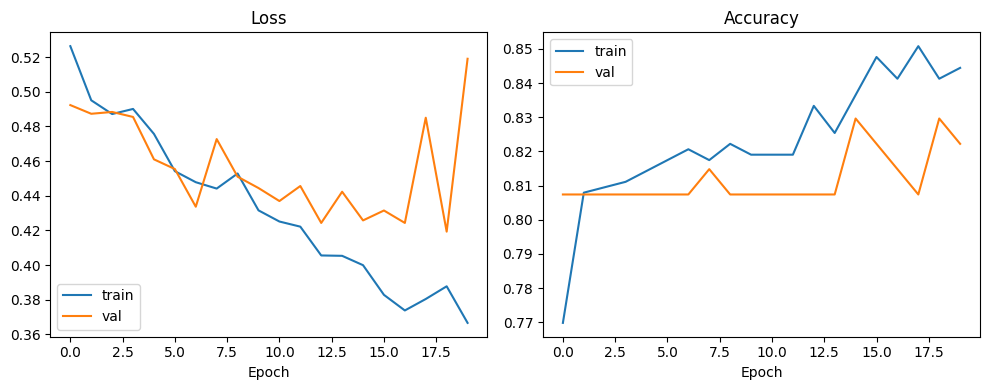

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## A6. Evaluation & Results

Metrics for a binary classifier: accuracy, precision, recall, F1, and a confusion matrix (so a single aggregate number can't hide poor performance on the minority class).


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step 
Accuracy:  0.800
Precision: 0.400
Recall:    0.077
F1:        0.129

              precision    recall  f1-score   support

      benign       0.82      0.97      0.89       109
   malignant       0.40      0.08      0.13        26

    accuracy                           0.80       135
   macro avg       0.61      0.52      0.51       135
weighted avg       0.74      0.80      0.74       135



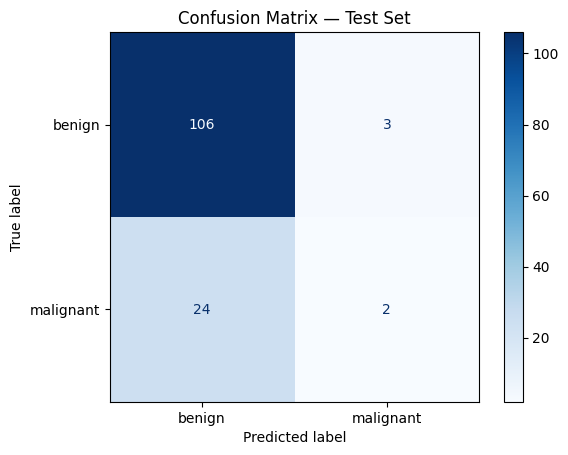

In [10]:
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

y_true = np.concatenate([y.numpy() for _, y in test_ds])

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.show()

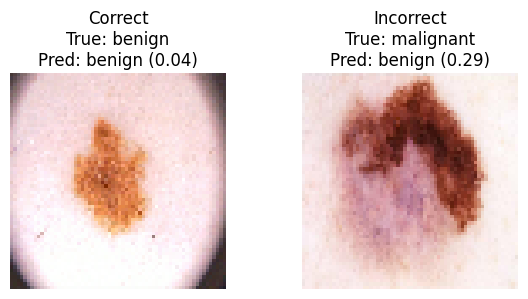

In [11]:
def load_display_image(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=CHANNELS, expand_animations=False)
    img = tf.image.resize(img, (img_size, img_size))
    img = img / 255.0
    return img.numpy()

y_test_arr = np.array(y_test)
correct_idx = np.where(y_pred == y_test_arr)[0]
incorrect_idx = np.where(y_pred != y_test_arr)[0]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

if len(correct_idx) > 0:
    i = correct_idx[0]
    img = load_display_image(X_test[i])
    axes[0].imshow(img)
    axes[0].set_title(f"Correct\nTrue: {CLASS_NAMES[y_test[i]]}\nPred: {CLASS_NAMES[y_pred[i]]} ({y_prob[i]:.2f})")
else:
    axes[0].set_title("No correct examples in this run")
axes[0].axis("off")

if len(incorrect_idx) > 0:
    i = incorrect_idx[0]
    img = load_display_image(X_test[i])
    axes[1].imshow(img)
    axes[1].set_title(f"Incorrect\nTrue: {CLASS_NAMES[y_test[i]]}\nPred: {CLASS_NAMES[y_pred[i]]} ({y_prob[i]:.2f})")
else:
    axes[1].set_title("No incorrect examples in this run")
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Interpreting the model's output:**
The model outputs a single float between 0 and 1 (a sigmoid activation), representing the 
predicted probability that the lesion is `malignant`:
- A value **≥ 0.5** → predicted class is `malignant`, with confidence = that value.
- A value **< 0.5** → predicted class is `benign`, with confidence = `1 - that value`.

This is fundamentally different from a softmax, multi-class output (as used in other imaging 
projects in this course) — there is no `argmax` step here, since there is only one output unit, 
not one unit per class. Any Streamlit app built against this model must apply the 0.5 threshold 
logic above, not a softmax-style class selection.

In [13]:
MODEL_PATH = "skin_lesion_model.keras"
model.save(MODEL_PATH)

print(f"Saved model to {MODEL_PATH}")
print("TensorFlow version used to save:", tf.__version__)
print("Expected input shape:", model.input_shape)


Saved model to skin_lesion_model.keras
TensorFlow version used to save: 2.20.0
Expected input shape: (None, 64, 64, 3)


In [14]:
import json
from pathlib import Path

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

model.save(MODEL_DIR / "skin_lesion_classifier.keras")

preprocessing_config = {
    "img_size": [IMG_SIZE, IMG_SIZE],
    "channels": CHANNELS,
    "rescale": 1.0 / 255.0,
    "channel_order": "RGB",
    "class_names": CLASS_NAMES,          
    "output_type": "binary_sigmoid",      
    "tf_version": tf.__version__,
}

with open(MODEL_DIR / "preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

## A8. Limitations, Ethics & Next Steps

**Data bias / generalisation:** ISIC datasets are well-documented in the dermatology AI 
literature as skewed toward lighter Fitzpatrick skin types, meaning this model's performance on 
darker skin tones is unverified and likely worse than reported here — this is a serious, known 
limitation, not a hypothetical one. Additionally, this subset (900 images from the ISIC 2016 
Task 3 challenge) comes from a single collection year/source rather than a demographically or 
geographically diverse pool, and no metadata was available to check whether performance differs 
by age, sex, or lesion body-site location. No subgroup analysis was possible with the information 
in this dataset, and that gap should be stated plainly rather than assumed away.

**False positives vs. false negatives:** in a malignancy-screening context, a **false negative** 
(missing a malignant lesion) is generally far more dangerous than a **false positive** (flagging 
a benign lesion for review), since a false negative could delay real treatment. Threshold choice 
and reported recall on the malignant class should reflect that asymmetry, not just overall 
accuracy — see A6 for this model's actual recall on the malignant class specifically.

**Why clinical oversight is required:** this model has not been validated against 
biopsy-confirmed outcomes at any clinically meaningful scale beyond the ISIC ground-truth labels 
themselves, was not developed under a regulatory framework, and has no mechanism for the kind of 
contextual judgement a dermatologist brings (patient history, lesion evolution over time, physical 
examination). It should only ever be positioned as a triage aid that a clinician reviews, never as 
a standalone decision-maker.

**What real clinical use would require:** validation on a large, demographically representative 
(including a range of skin tones), biopsy-confirmed dataset; prospective clinical trials; 
regulatory clearance (e.g. FDA/CE marking as appropriate); a clear human-in-the-loop workflow; and 
ongoing post-deployment monitoring for performance drift.